In [1]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd
from skgstat import models
import gstatsim as gsm
from scipy.ndimage import binary_dilation

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time

import sys
sys.path.append('../../src')
sys.path.append('../src')

import preprocessing
import block_update
import bouguer
import diagnostics
import rfgen
import utilities
import postprocessing
import gstatsim_custom
import gaussnewton

import importlib
importlib.reload(preprocessing)
importlib.reload(block_update)
importlib.reload(bouguer)
importlib.reload(diagnostics)
importlib.reload(rfgen)
importlib.reload(utilities)
importlib.reload(postprocessing)
importlib.reload(gstatsim_custom)
importlib.reload(gaussnewton)

from preprocessing import *
from block_update import *
from bouguer import *
from diagnostics import *
from rfgen import *
from utilities import *
from postprocessing import *
from gstatsim_custom import *
from gaussnewton import *

In [2]:
grid = xr.open_dataset(Path('D:/bedmachine/BedMachineAntarctica-v3.nc'))
hubs_continent = np.load(Path('../continent_hubs.npy'))

In [3]:
xx_bm, yy_bm = np.meshgrid(grid.x.values, grid.y.values)

ground_ice_mask = grid.mask.values == 2

data_coords = (xx_bm[ground_ice_mask], yy_bm[ground_ice_mask])
# distance_msk = vd.distance_mask(data_coords, 5e3, (xx_bm, yy_bm))
distance_msk = binary_dilation(ground_ice_mask, iterations=1)

boundary_msk = (ground_ice_mask ^ distance_msk) & (grid.mask.values == 3)

In [4]:
np.count_nonzero(boundary_msk)

104303

In [5]:
ii, jj = np.meshgrid(np.arange(grid.bed.shape[0]), np.arange(grid.bed.shape[1]), indexing='ij')

ibound = ii[boundary_msk==True]
jbound = jj[boundary_msk==True]

rng = np.random.default_rng(2)
rint = rng.integers(0, ibound.size, size=1)[0]
irand = ibound[rint]
jrand = jbound[rint]

route_mask = (grid.bed.values < hubs_continent[irand,jrand] + 5) & (ground_ice_mask==False)
groups = label(route_mask)
route_mask = (grid.bed.values < hubs_continent[irand,jrand] + 5) & (ground_ice_mask==False) & (groups==groups[irand,jrand])

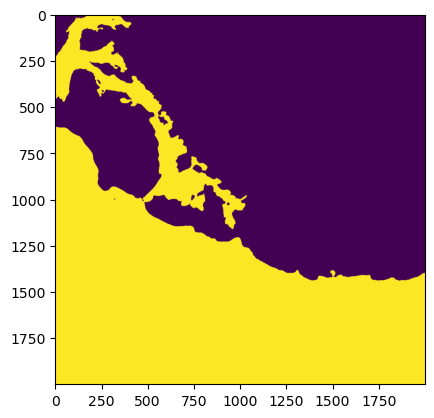

In [6]:
plt.imshow(route_mask[irand-1000:irand+1000,jrand-1000:jrand+1000])
plt.show()

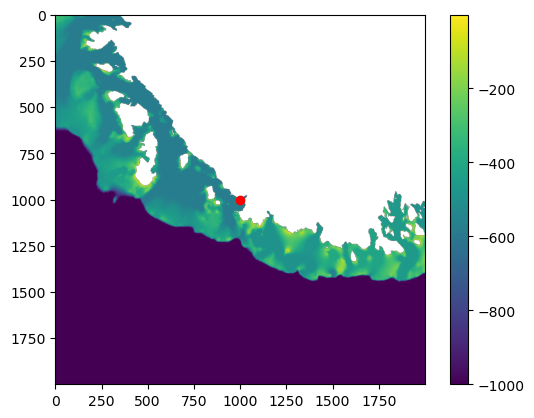

In [7]:
plt.imshow(hubs_continent[irand-1000:irand+1000,jrand-1000:jrand+1000], vmin=-1000)
plt.plot(1000,1000, 'ro')
plt.colorbar()
plt.show()

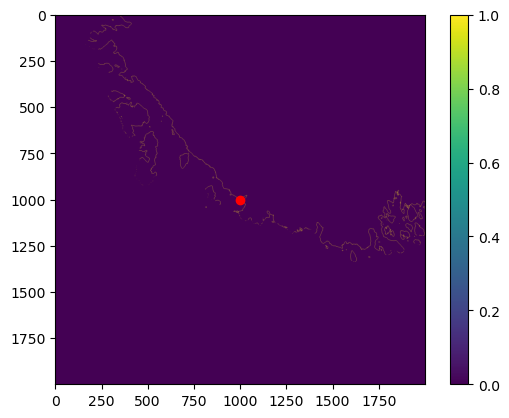

In [8]:
plt.imshow(boundary_msk[irand-1000:irand+1000,jrand-1000:jrand+1000])
plt.plot(1000,1000, 'ro')
plt.colorbar()
plt.show()

In [9]:
from copy import deepcopy

In [10]:
%%time

search = np.full_like(xx_bm, False)
search[irand, jrand] = True

msk_route = route_mask

i = 0
# while (np.count_nonzero(grid.bed.values[search==True] < -1500)==0) & (i < 800):
#     search = binary_dilation(search, mask=msk_route, iterations=50)
#     msk_route = hubs_continent <= hubs_continent[search==True].min() + 10
#     i += 1

while (np.count_nonzero(hubs_continent[search>1] < -1500)==0) & (i < 800):
    search += binary_dilation(search, mask=msk_route, iterations=100)
    msk_route = hubs_continent <= hubs_continent[search>1].min() + 10
    i += 1

CPU times: total: 19.6 s
Wall time: 19.6 s


In [11]:
shelf_valid = (search==True) & (grid.bed.values < -1500)

x_shelf = xx_bm[shelf_valid][0]
y_shelf = yy_bm[shelf_valid][0]

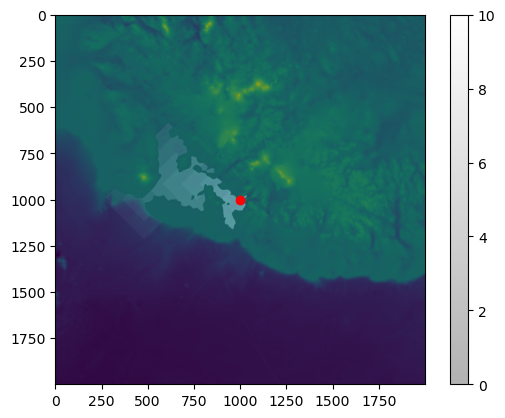

In [12]:
im = plt.imshow(grid.bed.values[irand-1000:irand+1000,jrand-1000:jrand+1000])
im = plt.imshow(search[irand-1000:irand+1000,jrand-1000:jrand+1000], cmap='binary_r', alpha=0.3)
plt.plot(1000,1000, 'ro')
plt.colorbar(im)
plt.show()

In [13]:
np.max(search)

np.int32(10)

In [14]:
hubs_continent[irand,jrand]

np.float64(-576.0)

In [15]:
hubs_trim = hubs_continent[irand-1000:irand+1000,jrand-1000:jrand+1000]
bound_trim = boundary_msk[irand-1000:irand+1000,jrand-1000:jrand+1000]

In [16]:
np.count_nonzero((hubs_trim > -345) & (hubs_trim < -340))

5382

In [17]:
np.count_nonzero(bound_trim)

9107

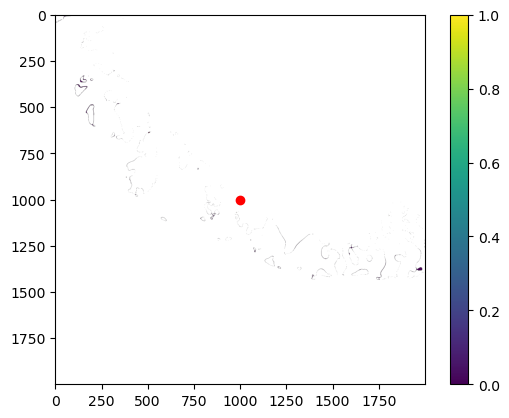

In [18]:
plt.imshow(np.where((hubs_trim > -345) & (hubs_trim < -340), bound_trim, np.nan))
plt.plot(1000,1000, 'ro')
plt.colorbar()
plt.show()

In [19]:
search = (hubs_continent > -345) & (hubs_continent < -340)

ii_route = ii[search]
jj_route = jj[search]

In [20]:
np.unique(groups)

array([   0,    1,    2, ..., 2195, 2196, 2197],
      shape=(2198,), dtype=int32)

In [21]:
groups[ii_route,jj_route]

array([0, 0, 0, ..., 0, 0, 0], shape=(96499,), dtype=int32)

In [22]:
route_mask = (grid.bed.values < -340) & (ground_ice_mask==False)
groups = label(route_mask)
route_mask = (grid.bed.values < -340) & (ground_ice_mask==False) & np.isin(groups, groups[ii_route,jj_route])

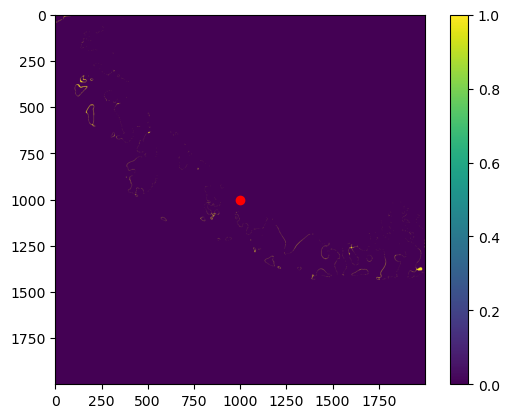

In [23]:
plt.imshow(search[irand-1000:irand+1000,jrand-1000:jrand+1000])
plt.plot(1000,1000, 'ro')
plt.colorbar()
plt.show()

In [24]:
# %%time

search = (hubs_continent > -345) & (hubs_continent < -340)

msk_route = route_mask

i = 0
# while (np.count_nonzero(grid.bed.values[search==True] < -1500)==0) & (i < 800):
#     search = binary_dilation(search, mask=msk_route, iterations=50)
#     msk_route = hubs_continent <= hubs_continent[search==True].min() + 10
#     i += 1

while (np.count_nonzero(grid.bed.values[search>=1] < -1500)==0) & (i < 800):
    search += binary_dilation(search, mask=msk_route, iterations=50)
    msk_route = hubs_continent <= hubs_continent[search>=1].min() + 10
    i += 1

In [25]:
hubs_continent[search>=1].min()

np.float64(-1999.0)

In [26]:
route_mask = (grid.bed.values < hubs_continent[irand,jrand] + 5) & (ground_ice_mask==False)
groups = label(route_mask)
route_mask = (grid.bed.values < hubs_continent[irand,jrand] + 5) & (ground_ice_mask==False) & (groups==groups[irand,jrand])

search = np.full_like(xx_bm, False)
search[irand, jrand] = True

msk_route = route_mask

In [27]:
i_search = irand
j_search = jrand

for i in range(100):
    i_new = rng.choose([-1, 1]).astype(int)
    j_new = rng.choose([-1,1]).astype(int)
    search += binary_dilation(search, mask=msk_route, iterations=50)
    msk_route = hubs_continent <= hubs_continent[search>1].min() + 10
    i += 1

AttributeError: 'numpy.random._generator.Generator' object has no attribute 'choose'

In [ ]:
tmp = (hubs_continent > -350) & (hubs_continent <= -310)
#groups = label(tmp, connectivity=2)
# tmp = tmp & (groups==groups[irand,jrand])

In [ ]:
np.unique(groups)

In [28]:
groups[irand,jrand]

np.int32(1)

In [29]:
np.count_nonzero(tmp)

NameError: name 'tmp' is not defined

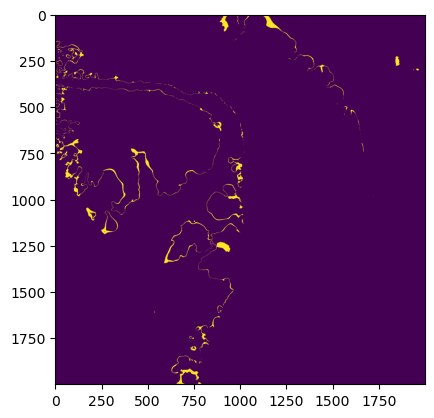

In [112]:
plt.imshow(tmp[irand-1000:irand+1000,jrand-1000:jrand+1000])
plt.show()

In [119]:
%%time

max_hub = hubs_continent[irand,jrand]
min_hub = max_hub
search = np.full(xx_bm.shape, False)
dz = 5

i = 0
while (np.count_nonzero(grid.bed.values[search==1] < -1500)==0) & (i < 800):
    tmp = (hubs_continent > max_hub-dz) & (hubs_continent <= max_hub)
    search = search | tmp
    groups = label(search, connectivity=2)
    search = groups==groups[irand,jrand]
    max_hub -= dz
    i += 1

CPU times: total: 37.8 s
Wall time: 37.8 s


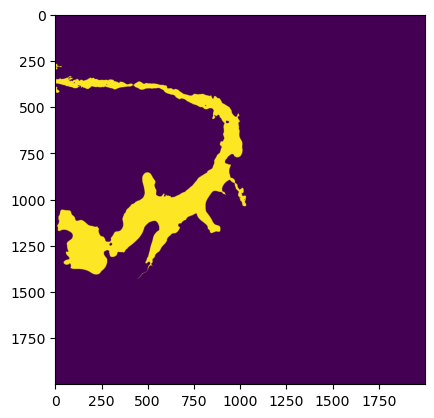

In [120]:
plt.imshow(search[irand-1000:irand+1000,jrand-1000:jrand+1000])
plt.show()

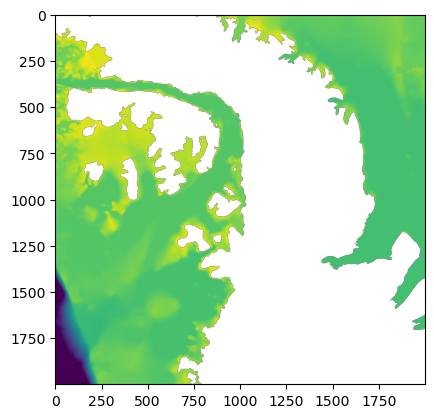

In [121]:
plt.imshow(hubs_trim)
plt.show()

## Try on coarsened BedMachine

In [2]:
# ds = xr.open_dataset(Path('D:/bedmachine/BedMachineAntarctica-v3.nc'))
ds = xr.open_dataset(Path('../../stochastic_bathymetry/raw_data/bedmachine/BedMachineAntarctica-v3.nc'))

In [3]:
%%time

ds_coarse = ds.coarsen(x=10, y=10, boundary='trim').median()
# print(np.unique(ds.mask.values))
# msk = np.where(ds.mask.values==1.5, 3, ds.mask.values)

# ds['mask'] = (('y', 'x'), np.ceil(msk).astype(np.int8))

CPU times: total: 28.5 s
Wall time: 29 s


In [4]:
xx_bm, yy_bm = np.meshgrid(ds.x, ds.y)
xx_coarse, yy_coarse = np.meshgrid(ds_coarse.x, ds_coarse.y)

kn = vd.KNeighbors(k=1)
kn.fit((xx_bm, yy_bm), ds.mask.values)
mask_preds = kn.predict((xx_coarse, yy_coarse))
mask_preds.shape

(1333, 1333)

In [5]:
ds_coarse['mask'] = (('y', 'x'), mask_preds)
ds = ds_coarse

In [6]:
# make sure surface is 0 in open water
ds['surface'] = (('y', 'x'), np.where(ds.mask==0, 0, ds.surface))

# make sure thickness is 0 in open water and at exposed rock
ocean_rock_msk = (ds.mask==0)^(ds.mask==1)
ds['thickness'] = (('y', 'x'), np.where(ocean_rock_msk, 0, ds.thickness))

# make sure bed is equal to surface minus thickness under grounded ice
ds['bed'] = (('y', 'x'), np.where(ds.mask==2, ds.surface-ds.thickness, ds.bed))

# make sure surface is equal to bed at exposed rock
ds['bed'] = (('y', 'x'), np.where(ds.mask==1, ds.surface, ds.bed))

# make sure bed not above ice in ice shelf
bed_above_ice_bottom = np.where(ds.bed > (ds.surface-ds.thickness), True, False)
ds['bed'] = (('y', 'x'), np.where(bed_above_ice_bottom, ds.surface-ds.thickness, ds.bed))

# make mask grounded ice where bed was above ice bottom
ds['mask'] = (('y', 'x'), np.where(bed_above_ice_bottom, 2, ds.mask))

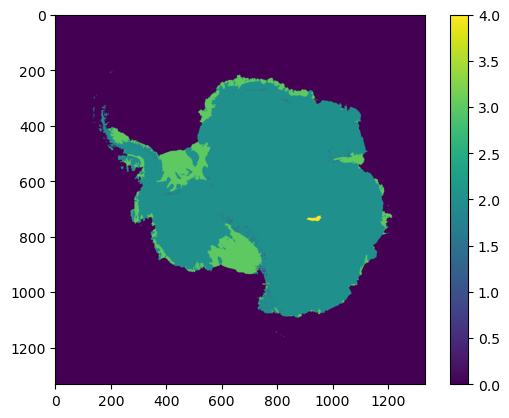

In [7]:
plt.imshow(ds.mask)
plt.colorbar()
plt.show()

In [8]:
water_msk = (ds.mask.values==0) | (ds.mask.values==3)

bed = ds.bed.values
min_bed = -2000
max_bed = bed[water_msk].max()
vert_res = 1

In [9]:
hubs = hub_elevations(ds, bed, water_msk, min_bed, max_bed, vert_res, save_connects=False)
hubs = np.where(hubs > 0, 0, hubs)

  0%|          | 0/2187 [00:00<?, ?it/s]

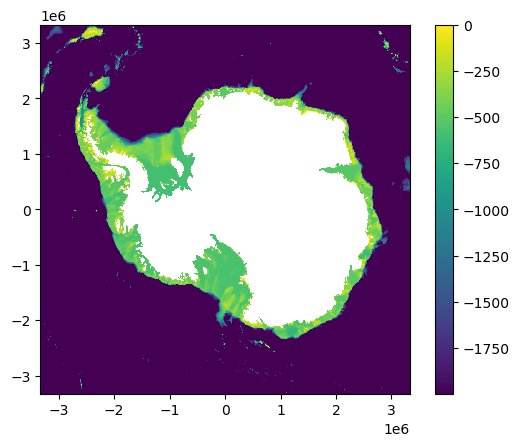

In [10]:
plt.pcolormesh(ds.x, ds.y, hubs)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [11]:
xx_bm, yy_bm = np.meshgrid(ds.x.values, ds.y.values)

ground_ice_mask = ds.mask.values == 2

data_coords = (xx_bm[ground_ice_mask], yy_bm[ground_ice_mask])
# distance_msk = vd.distance_mask(data_coords, 5e3*np.sqrt(2), (xx_bm, yy_bm))
distance_msk = binary_dilation(ground_ice_mask, iterations=1)

boundary_msk = (ground_ice_mask ^ distance_msk) & (ds.mask.values == 3) & (~np.isnan(hubs))

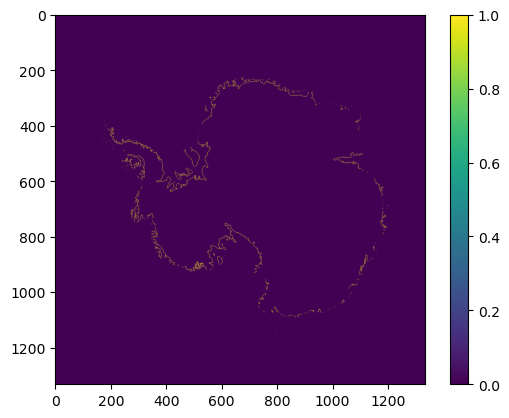

In [12]:
plt.imshow(boundary_msk)
plt.colorbar()
plt.show()

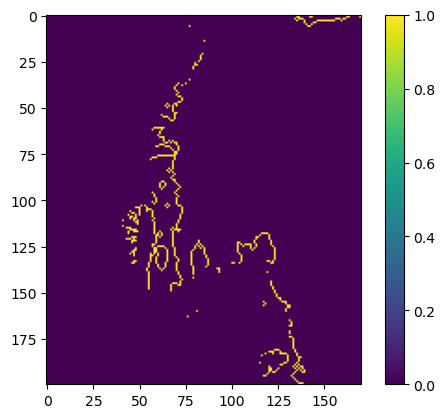

In [13]:
plt.imshow(boundary_msk[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [14]:
np.count_nonzero(boundary_msk)

6867

In [15]:
ii, jj = np.meshgrid(np.arange(ds.bed.shape[0]), np.arange(ds.bed.shape[1]), indexing='ij')

ibound = ii[boundary_msk==True]
jbound = jj[boundary_msk==True]

rng = np.random.default_rng(1)
rint = rng.integers(0, ibound.size, size=1)[0]
irand = ibound[1039]
jrand = jbound[1039]

route_mask = (ds.bed.values < hubs[irand,jrand] + 5) & (ground_ice_mask==False)
groups = label(route_mask)
route_mask = (ds.bed.values < hubs[irand,jrand] + 5) & (ground_ice_mask==False) & (groups==groups[irand,jrand]) & (~np.isnan(hubs))

In [16]:
hubs[irand,jrand]

np.float64(-244.0)

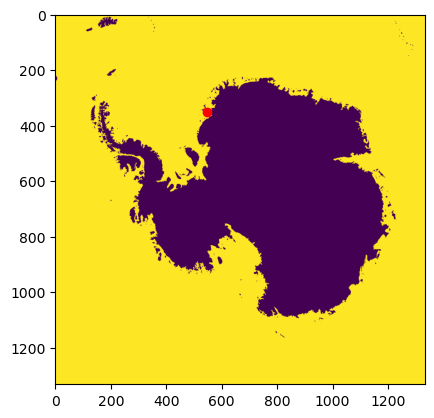

In [17]:
plt.imshow(route_mask)
plt.plot(jrand,irand, 'ro')
plt.show()

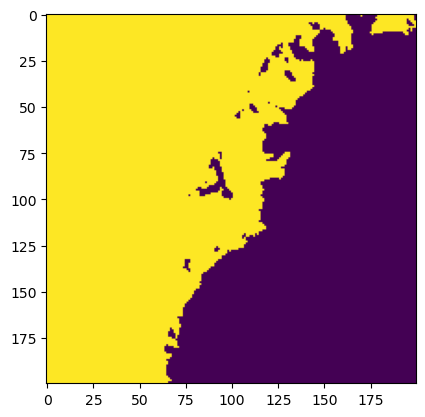

In [18]:
plt.imshow(route_mask[irand-100:irand+100,jrand-100:jrand+100])
plt.show()

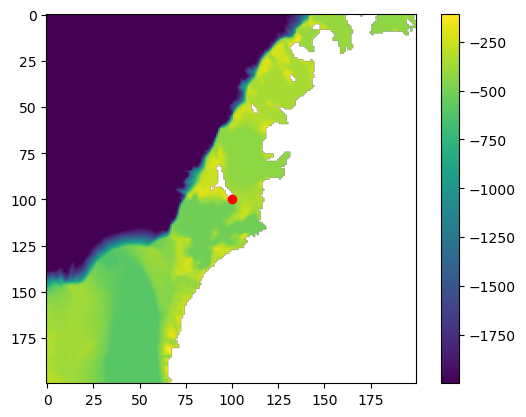

In [19]:
plt.imshow(hubs[irand-100:irand+100,jrand-100:jrand+100])
plt.plot(100,100, 'ro')
plt.colorbar()
plt.show()

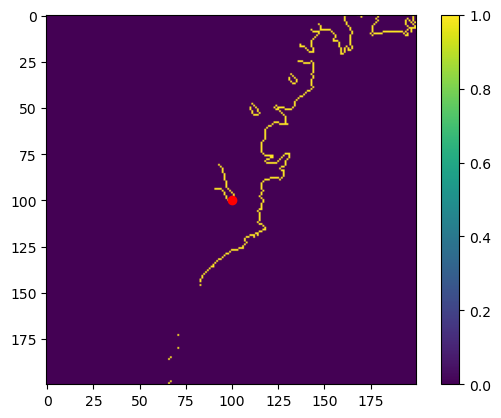

In [20]:
plt.imshow(boundary_msk[irand-100:irand+100,jrand-100:jrand+100])
plt.plot(100,100, 'ro')
plt.colorbar()
plt.show()

In [21]:
%%time

search = np.full_like(xx_bm, False)
search[irand, jrand] = True

msk_route = route_mask

# i = 0
# while (np.count_nonzero(hubs[search==True] < -1500)==0) & (i < 800):
#     search = binary_dilation(search, mask=msk_route, iterations=10)
#     msk_route = hubs <= hubs[search==True].min() + 10
#     i += 1

i = 0
while (np.count_nonzero(hubs[search>1] < -1500)==0) & (i < 10000):
    search += binary_dilation(search, mask=msk_route, iterations=20)
    msk_route = hubs <= hubs[search>1].min()
    i += 1

CPU times: total: 78.1 ms
Wall time: 72.1 ms


In [22]:
i

3

In [23]:
shelf_valid = (search==True) & (ds.bed.values < -1500)

x_shelf = xx_bm[shelf_valid][0]
y_shelf = yy_bm[shelf_valid][0]

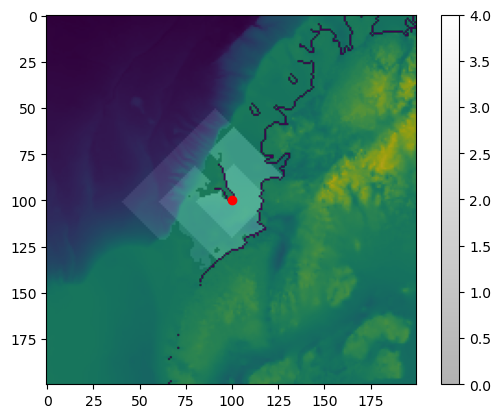

In [24]:
im = plt.imshow(ds.bed.values[irand-100:irand+100,jrand-100:jrand+100])
im = plt.imshow(search[irand-100:irand+100,jrand-100:jrand+100], cmap='binary_r', alpha=0.3)
plt.imshow(np.where(boundary_msk, True, np.nan)[irand-100:irand+100,jrand-100:jrand+100])
plt.plot(100,100, 'ro')
plt.colorbar(im)
plt.show()

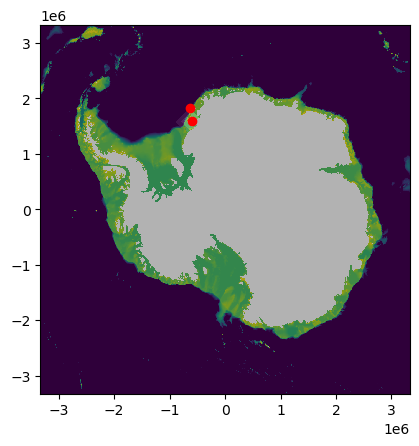

In [25]:
plt.pcolormesh(ds.x, ds.y, hubs)
plt.pcolormesh(ds.x, ds.y, search, cmap='binary_r', alpha=0.3)
plt.plot(xx_bm[irand,jrand], yy_bm[irand,jrand], 'ro')
plt.plot(x_shelf, y_shelf, 'ro')
plt.axis('scaled')
plt.show()

In [26]:
hubs[search>1].min()

np.float64(-1999.0)

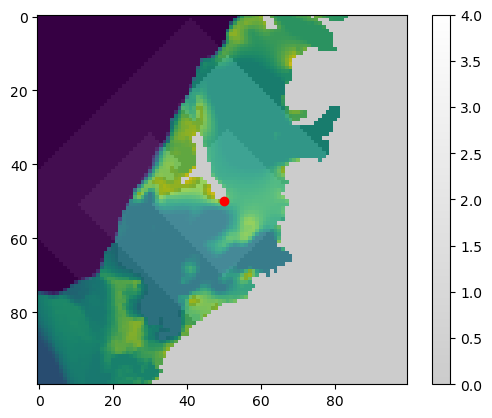

In [27]:
im = plt.imshow(hubs[irand-50:irand+50,jrand-50:jrand+50], vmin=-800)
im = plt.imshow(search[irand-50:irand+50,jrand-50:jrand+50], cmap='binary_r', alpha=0.2)
plt.plot(50,50, 'ro')
plt.colorbar(im)
plt.show()

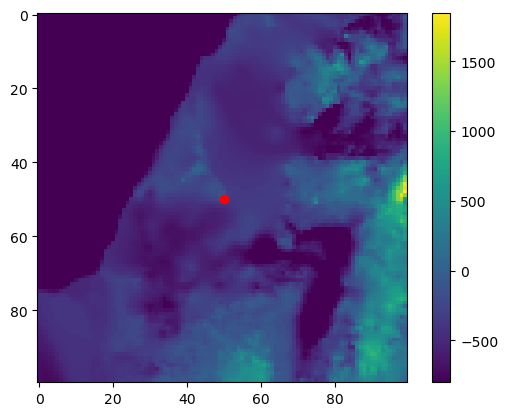

In [28]:
im = plt.imshow(ds.bed.values[irand-50:irand+50,jrand-50:jrand+50], vmin=-800)
# im = plt.imshow(search[irand-50:irand+50,jrand-50:jrand+50], cmap='binary_r', alpha=0.2)
plt.plot(50,50, 'ro')
plt.colorbar(im)
plt.show()

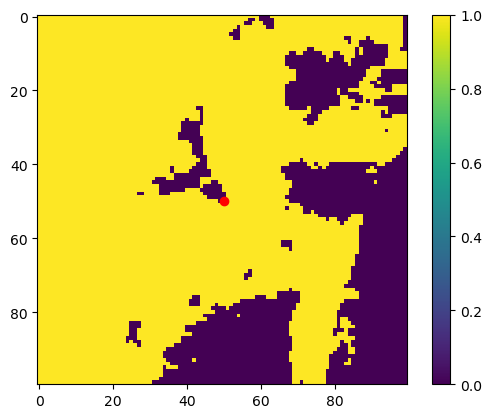

In [29]:
im = plt.imshow(ds.bed.values[irand-50:irand+50,jrand-50:jrand+50] < ds.bed.values[irand,jrand])
# im = plt.imshow(search[irand-50:irand+50,jrand-50:jrand+50], cmap='binary_r', alpha=0.2)
plt.plot(50,50, 'ro')
plt.colorbar(im)
plt.show()

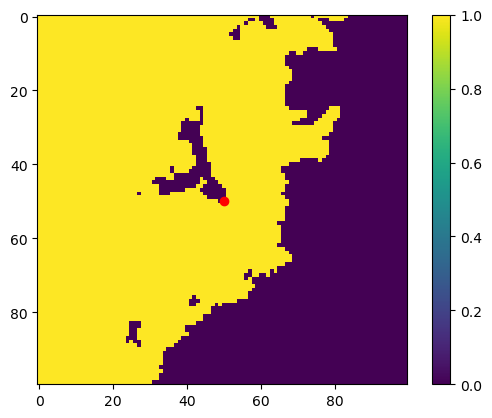

In [30]:
im = plt.imshow(hubs[irand-50:irand+50,jrand-50:jrand+50]<=hubs[irand,jrand])
# im = plt.imshow(search[irand-50:irand+50,jrand-50:jrand+50], cmap='binary_r', alpha=0.2)
plt.plot(50,50, 'ro')
plt.colorbar(im)
plt.show()

In [31]:
nearest_x = np.full(ibound.size, np.nan)
nearest_y = np.full(ibound.size, np.nan)

for k in tqdm(range(ibound.shape[0])):
    i = ibound[k]
    j = jbound[k]
    
    search = np.full_like(xx_bm, False)
    search[i, j] = True

    route_mask = (ds.bed.values < hubs[i,j] + 5) & (ground_ice_mask==False)
    groups = label(route_mask)
    route_mask = (ds.bed.values < hubs[i,j] + 5) & (ground_ice_mask==False) & (groups==groups[i,j]) & (~np.isnan(hubs))
    
    msk_route = route_mask
    
    l = 0
    while (np.count_nonzero(hubs[search==True] < -1500)==0) & (l < 10000):
        search = binary_dilation(search, mask=msk_route, iterations=20)
        msk_route = hubs <= hubs[search==True].min()
        l += 1
    
    # while (np.count_nonzero(hubs[search>1] < -1500)==0) & (i < 10000):
    #     search += binary_dilation(search, mask=msk_route, iterations=10)
    #     msk_route = hubs <= hubs[search>1].min() + 10
    #     i += 1

    shelf_valid = (search==True) & (hubs < -1500)
    if np.count_nonzero(shelf_valid) > 0:
        x_shelf = xx_bm[shelf_valid][0]
        y_shelf = yy_bm[shelf_valid][0]
    else:
        x_shelf = np.nan
        y_shelf = np.nan

    nearest_x[k] = x_shelf
    nearest_y[k] = y_shelf

  0%|          | 0/6867 [00:00<?, ?it/s]

In [32]:
np.count_nonzero(np.isnan(nearest_x))

0

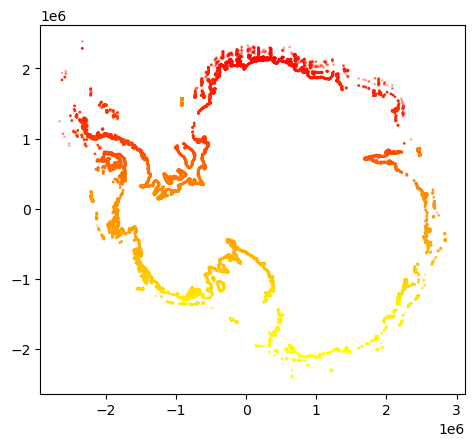

In [33]:
#plt.pcolormesh(ds.x, ds.y, hubs)
plt.scatter(xx_bm[ibound,jbound], yy_bm[ibound,jbound], c=np.arange(ibound.size), s=1, cmap='autumn')
plt.scatter(nearest_x, nearest_y, c=np.arange(ibound.size), s=1, cmap='autumn', alpha=0.3)
plt.axis('scaled')
plt.show()

# WOA

In [34]:
temp = xr.open_dataset(Path('D:/WOA/woa18_decav81B0_t04_01.nc'), decode_times=False)
sal = xr.open_dataset(Path('D:/WOA/woa18_decav81B0_s04_01.nc'), decode_times=False)

In [35]:
temp

<xarray.Dataset> Size: 148MB
Dimensions:             (lat: 180, nbounds: 2, lon: 360, depth: 57, time: 1)
Coordinates:
  * lat                 (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                 (lon) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * depth               (depth) float32 228B 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * time                (time) float32 4B 171.5
Dimensions without coordinates: nbounds
Data variables: (12/13)
    crs                 int32 4B ...
    lat_bnds            (lat, nbounds) float32 1kB ...
    lon_bnds            (lon, nbounds) float32 3kB ...
    depth_bnds          (depth, nbounds) float32 456B ...
    climatology_bounds  (time, nbounds) float32 8B ...
    t_an                (time, depth, lat, lon) float32 15MB ...
    ...                  ...
    t_dd                (time, depth, lat, lon) float64 30MB ...
    t_sd                (time, depth, lat, lon) float32 15MB ...
    t_se                (time, depth, lat, lon) float32 15MB ...
    t_oa                (time, depth, lat, lon) float32 15MB ...
    t_ma                (time, depth, lat, lon) float32 15MB ...
    t_gp                (time, depth, lat, lon) float64 30MB ...
Attributes: (12/49)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           World Ocean Atlas 2018 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R. A., A. V. Mishonov, O. K. ...
    institution:                     National Centers for Environmental Infor...
    comment:                         global climatology as part of the World ...
    ...                              ...
    publisher_email:                 NCEI.info@noaa.gov
    nodc_template_version:           NODC_NetCDF_Grid_Template_v2.0
    license:                         These data are openly available to the p...
    metadata_link:                   https://www.nodc.noaa.gov/OC5/woa18/
    date_created:                    2019-07-28 
    date_modified:                   2019-07-28

In [36]:
import pyproj

sal = sal.where(sal.lat<-60,drop=True)
temp= temp.where(sal.lat<-60,drop=True)
lons=sal.lon.values
lats=sal.lat.values
projection = pyproj.Proj("epsg:3031")
lons,lats = np.meshgrid(sal.lon,sal.lat)
x,y = projection.transform(lons,lats)
sal.coords["x"]= (("lat","lon"),x)
sal.coords["y"]= (("lat","lon"),y)
temp.coords["x"]= (("lat","lon"),x)
temp.coords["y"]= (("lat","lon"),y)

sal = sal.isel(time=0)
temp = temp.isel(time=0)

In [37]:
some_temp = temp.t_an.sel(depth=10.0).values

In [38]:
import cartopy.crs as ccrs

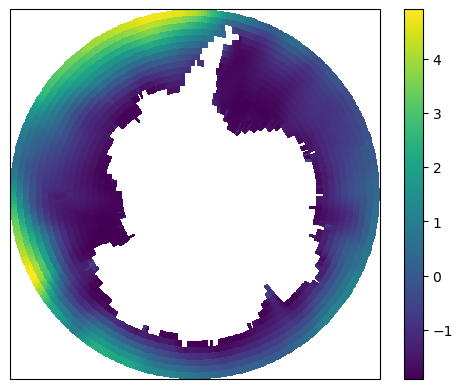

In [39]:
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.SouthPolarStereo(central_longitude=-71)))
im = ax.pcolormesh(temp.lon, temp.lat, some_temp, transform=ccrs.PlateCarree())
ax.axis('scaled')
plt.colorbar(im, ax=ax)
plt.show()

In [40]:
temp.depth

<xarray.DataArray 'depth' (depth: 57)> Size: 228B
array([   0.,    5.,   10.,   15.,   20.,   25.,   30.,   35.,   40.,   45.,
         50.,   55.,   60.,   65.,   70.,   75.,   80.,   85.,   90.,   95.,
        100.,  125.,  150.,  175.,  200.,  225.,  250.,  275.,  300.,  325.,
        350.,  375.,  400.,  425.,  450.,  475.,  500.,  550.,  600.,  650.,
        700.,  750.,  800.,  850.,  900.,  950., 1000., 1050., 1100., 1150.,
       1200., 1250., 1300., 1350., 1400., 1450., 1500.], dtype=float32)
Coordinates:
  * depth    (depth) float32 228B 0.0 5.0 10.0 15.0 ... 1.4e+03 1.45e+03 1.5e+03
    time     float32 4B 171.5
Attributes:
    standard_name:  depth
    bounds:         depth_bnds
    positive:       down
    units:          meters
    axis:           Z

In [41]:
woa_mask = ~np.isnan(sal.s_an.sel(depth=1500.0).values)

In [42]:
%%time

xx_woa = sal.x.values.reshape(woa_mask.shape)
yy_woa = sal.y.values.reshape(woa_mask.shape)
ii_woa, jj_woa = np.meshgrid(np.arange(xx_woa.shape[0]), np.arange(xx_woa.shape[1]), indexing='ij')

woa_coords = np.array([xx_woa[woa_mask], yy_woa[woa_mask]]).T
woa_indices = np.array([ii_woa[woa_mask], jj_woa[woa_mask]]).T

tree = KDTree(woa_coords)
distances, indices = tree.query(np.array([nearest_x, nearest_y]).T)

CPU times: total: 0 ns
Wall time: 7.09 ms


In [43]:
distances

array([63966.30652382, 44864.40150157, 31836.59644908, ...,
       97965.39359605, 24026.87106437, 39598.10862972], shape=(6867,))

In [44]:
indices

array([3153,  624,  624, ..., 1607,  850,  850], shape=(6867,))

In [45]:
nearest_shelf_coords = woa_coords[indices,:]
nearest_shelf_indices = woa_indices[indices,:]

nearest_shelf_indices.shape

(6867, 2)

In [46]:
iinds = nearest_shelf_indices[:,0]
jinds = nearest_shelf_indices[:,1]

In [47]:
import gsw

In [48]:
d  = sal.depth.values
salvals = sal.s_an.values
tempvals = temp.t_an.values

t = tempvals[:, iinds, jinds]
s = salvals[:, iinds, jinds]

lonlon, latlat = np.meshgrid(sal.lon, sal.lat)
lons = lonlon[iinds, jinds]
lats = latlat[iinds, jinds]

for i, di in enumerate(d):
    s[i,:] = gsw.SA_from_SP(s[i,:],di,lons,lats)
    t[i,:] = gsw.CT_from_t(s[i,:],t[i,:],di)

# s = gsw.SA_from_SP(s,d,lons,lats)
#FOR MIMOC MAKE PT
#t = gsw.CT_from_pt(s,t)
# t = gsw.CT_from_t(s,t,d)

t.shape, s.shape

((57, 6867), (57, 6867))

In [49]:
n_gl = iinds.shape[0]

heats = np.full(n_gl, np.nan)
cdws = np.full(n_gl, np.nan)
gprimes = np.full(n_gl, np.nan)

In [50]:
from scipy.interpolate import make_interp_spline

In [51]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def heat_content(heat_function, depth, plusminus):
    depth = np.abs(depth)
    xnew= np.arange(max(5,depth-plusminus),depth)
    #xnew= np.arange(max(0,depth-plusminus),min(depth+plusminus,1500))
    ynew = heat_function[0](xnew)
    ynew = ynew - gsw.CT_freezing(heat_function[1](xnew),xnew,0)
    if len(ynew)>0:
        return np.trapz(ynew,xnew)/len(xnew)
        #return np.max(ynew)
    else:
        return np.nan

def pycnocline(heat_function,hub,shelf_key=None,lat=None,lon=None,debug=False):
    hub = np.abs(hub)
    zi = np.arange(5,1500,1)
    ti = moving_average(heat_function[0](zi),50)
    si = moving_average(heat_function[1](zi),50)
    zi = moving_average(zi,50)

    di = gsw.rho(si,ti,zi)
    dizi = np.abs(np.diff(di)/np.diff(zi))
    thresh = np.quantile(dizi,0.85)
    zpyc = np.mean(zi[1:][dizi>thresh])
    zpyci = np.argmin(np.abs(zi-zpyc))
    deltaH = -(zpyc)+(hub)

    if debug:
        fig,(ax1,ax2) = plt.subplots(1,2)
        ax1.plot(ti,-zi)
        ax2.plot(ti,-zi)
        ax1.axhline(y=-hub,color="blue",label="HUB")
        ax1.legend()
        plt.title(str(round(lat,1))+" , "+str(round(lon,1)))
        plt.show()

        fig,(ax1,ax2) = plt.subplots(1,2)
        ax1.plot(di,-zi)
        ax1.axhline(y=-zpyc,color="red",label="Pycnocline")
        ax1.axhline(y=-hub,color="blue",label="HUB")
        ax2.plot(ti,-zi)
        ax1.legend()
        plt.title(str(round(lat,1))+" , "+str(round(lon,1)))
        plt.show()

        
    if ~(np.isnan(di).all()):
        return deltaH
    else:
        return np.nan

def gprime(heat_function,hub,shelf_key=None,lat=None,lon=None,debug=False):
    hub = np.abs(hub)
    zi = np.arange(5,1500,1)
    ti = heat_function[0](zi)
    si = heat_function[1](zi)
    di = gsw.rho(si,ti,zi)

    di = moving_average(di,50)
    zi = moving_average(zi,50)
    ti = moving_average(ti,50)
    si = moving_average(si,50)

    dizi = np.abs(np.diff(di)/np.diff(zi))
    thresh = np.quantile(dizi,0.85)
    zpyc = np.mean(zi[1:][dizi>thresh])
    zpyci = np.argmin(np.abs(zi-zpyc))
    di = gsw.rho(si,ti,zpyc)

    rho_1i = np.logical_and(zi<zi[zpyci],zi>zi[zpyci]-50)
    rho_2i = np.logical_and(zi<zi[zpyci]+50,zi>zi[zpyci])
    gprime_ext = 9.8*(np.mean(di[rho_1i])-np.mean(di[rho_2i]))/np.mean(di[np.logical_or(rho_1i,rho_2i)])

    if debug:
        fig,(ax1,ax2) = plt.subplots(1,2)
        ax1.plot(di,-zi)
        ax1.axhline(y=-zpyc,color="red",label="pyc")
        ax1.axhline(y=-hub,color="blue",label="hub")
        ax2.axhline(y=-mld,color="green",label="mld")
        ax2.plot(ti,-zi)
        ax1.legend()
        plt.title(str(round(lat,1))+" , "+str(round(lon,1)))
        plt.show()
        
    if ~(np.isnan(di).all()):
        return abs(gprime_ext)
    else:
        return np.nan

In [52]:
baths = hubs[boundary_msk]

In [53]:
for i in tqdm(range(n_gl)):
    tinterp = make_interp_spline(d, t[:,i])
    sinterp = make_interp_spline(d, s[:,i])

    lon = lons[i]
    lat = lats[i]
    
    if np.isnan(t[11:,i]).all():
        heats[i] = np.nan
        
    elif np.nanmax(d[~np.isnan(t[:,i])]) > np.abs(baths[i]):
        heats[i] = heat_content((tinterp,sinterp), baths[i], 100)
        cdws[i] = pycnocline((tinterp,sinterp), baths[i], shelf_key=None, lat=lat, lon=lon)
        gprimes[i] = gprime((tinterp,sinterp), baths[i], shelf_key=None, lat=lat, lon=lon)

  0%|          | 0/6867 [00:00<?, ?it/s]

In [54]:
np.count_nonzero(np.isnan(heats))

23

In [55]:
np.count_nonzero(np.isnan(cdws))

0

In [56]:
np.count_nonzero(np.isnan(gprimes))

0

In [57]:
def emplace_data(mask, values, fill=np.nan, dtype=np.float64):
    grd = np.full_like(mask, fill, dtype=dtype)
    np.place(grd, mask, values)
    return grd

In [58]:
heats_grid = emplace_data(boundary_msk, heats)
cdws_grid = emplace_data(boundary_msk, cdws)
gprimes_grid = emplace_data(boundary_msk, gprimes)

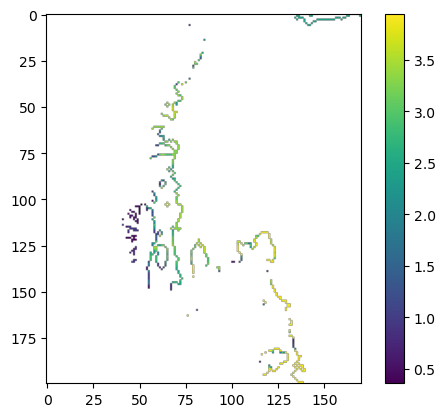

In [59]:
plt.imshow(heats_grid[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

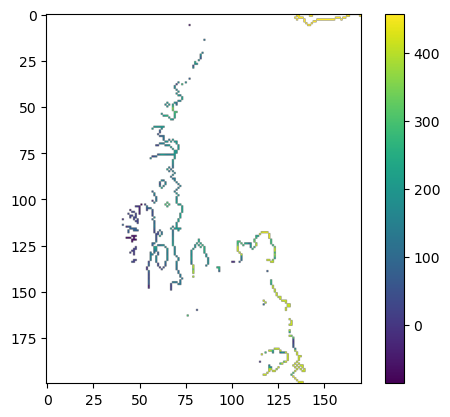

In [60]:
plt.imshow(cdws_grid[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

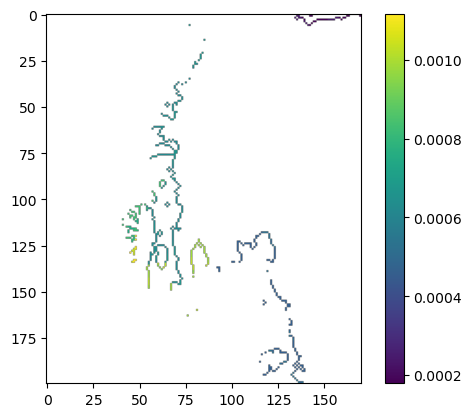

In [61]:
plt.imshow(gprimes_grid[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [62]:
lon_bm, lat_bm = projection(xx_bm[boundary_msk], yy_bm[boundary_msk], inverse=True)

fs = emplace_data(boundary_msk, 1/np.abs(gsw.f(lat_bm)))

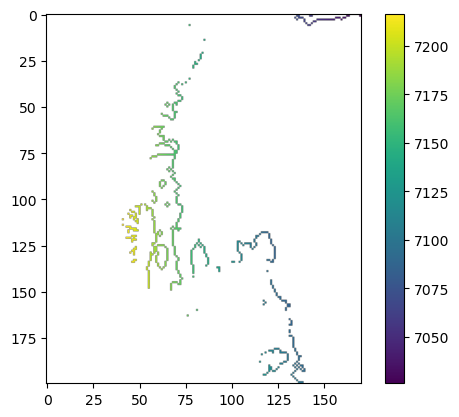

In [63]:
plt.imshow(fs[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [64]:
water_top = ds.surface.values - ds.thickness.values

dx, dy = np.gradient(water_top, 500)

slope = np.sqrt(dx**2 + dy**2)
slope = np.where(boundary_msk, slope, np.nan)

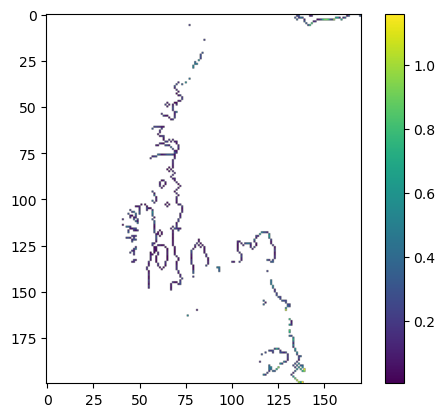

In [65]:
plt.imshow(slope[600:800,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [66]:
melts = cdws_grid * heats_grid *gprimes_grid * slope * fs

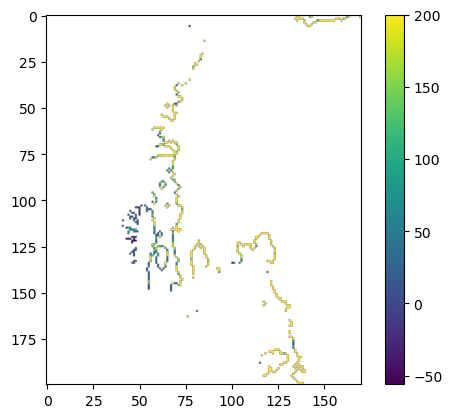

In [67]:
plt.imshow(melts[600:800,230:400], vmax=200)
plt.axis('scaled')
plt.colorbar()
plt.show()

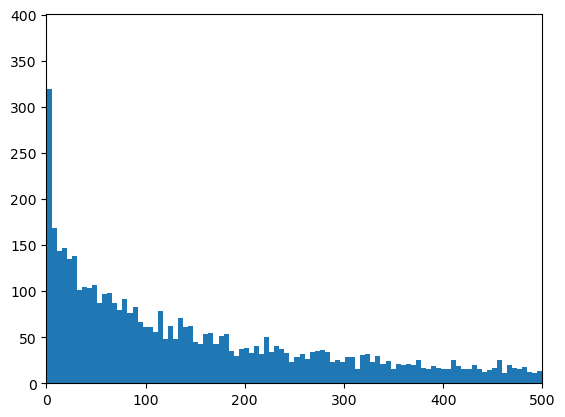

In [68]:
plt.hist(melts[~np.isnan(melts)], bins=100, range=(-10, 500))
plt.xlim(0, 500)
# plt.ylim(0, 20e3)
plt.show()

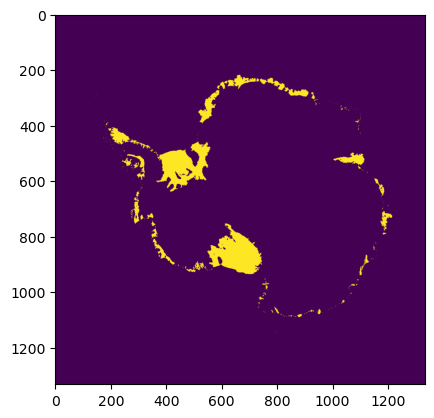

In [69]:
plt.imshow(ds.mask.values==3)
plt.show()

In [70]:
groups = label(ds.mask.values==3)

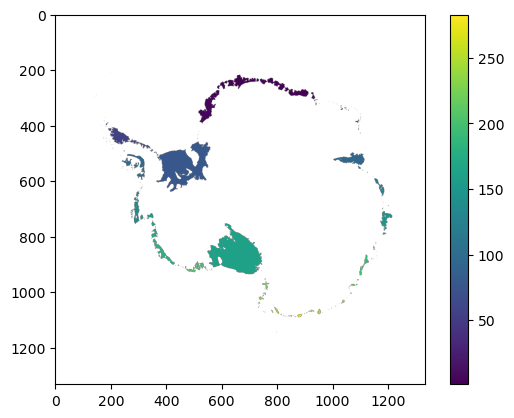

In [71]:
plt.imshow(np.where(groups==0, np.nan, groups))
plt.colorbar()
plt.show()

In [72]:
slopes = dict()

In [73]:
ii.shape

(1333, 1333)

In [74]:
icebottom = ds.surface.values - ds.thickness.values

In [75]:
uniq_shelf = np.unique(groups)
slope_map = np.full(xx_bm.shape, np.nan)

for shelf_id in uniq_shelf:
    if shelf_id==0:
        continue
    mask_shelf = groups==shelf_id
    if np.count_nonzero(mask_shelf)>10:
        X = ii[mask_shelf]
        X -= X.min()
        Y = jj[mask_shelf]
        Y -= Y.min()
        b = icebottom[mask_shelf]
    
        A = np.vstack([X,Y, np.ones(len(X))]).T
        m1, m2, c = np.linalg.lstsq(A, b, rcond=None)[0]
        m1 = np.abs(m1/5000)
        m2 = np.abs(m2/5000)
        slope_shelf = np.sqrt(m1**2+m2**2)
        slopes[shelf_id] = slope_shelf
    
        slope_map[mask_shelf] = slope_shelf

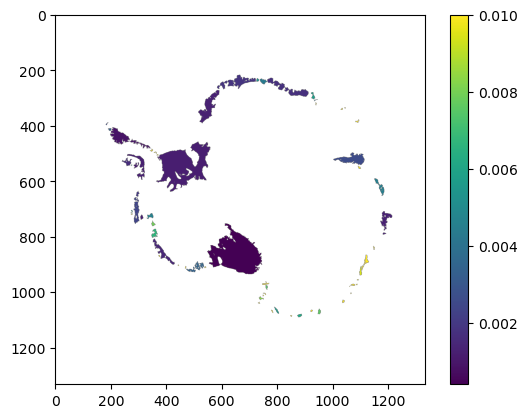

In [76]:
plt.imshow(slope_map, vmax=0.01)
plt.colorbar()
plt.show()

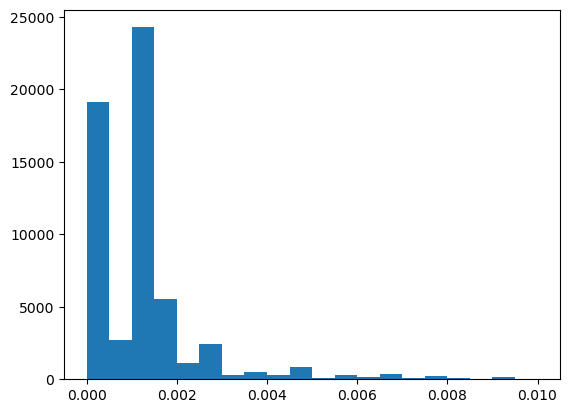

In [77]:
plt.hist(slope_map[(~np.isnan(slope_map))], bins=20, range=(0,0.01))
plt.show()

In [78]:
vals = np.array(list(slopes.values()))
vals.size

66

In [79]:
vals[vals > 0].size

66

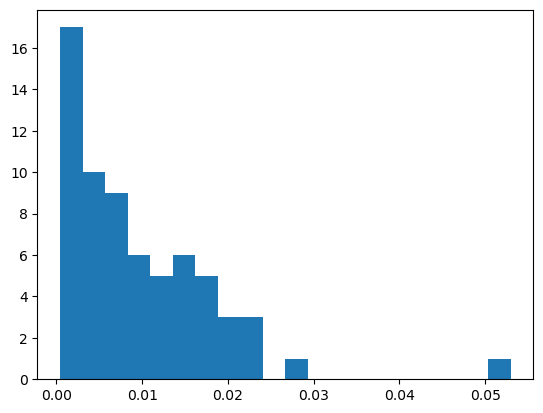

In [80]:
plt.hist(vals[vals > 0], bins=20)
plt.show()

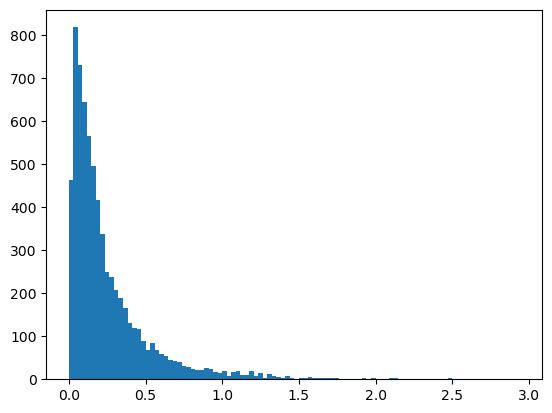

In [81]:
plt.hist(slope[~np.isnan(slope)], bins=100)
plt.show()

In [82]:
melts2 = cdws_grid * heats_grid *gprimes_grid * slope_map * fs

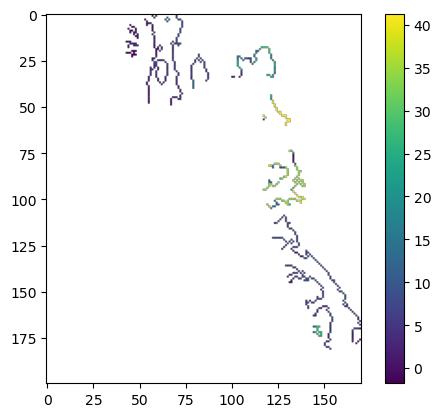

In [83]:
plt.imshow(melts2[700:900,230:400])
plt.axis('scaled')
plt.colorbar()
plt.show()

In [84]:
import geopandas as gpd

In [85]:
gdf = gpd.read_file(Path('../raw_data/regions/IceBoundaries_Antarctica_v02.shp'))
gdf

,NAME,Regions,Subregions,TYPE,Asso_Shelf,geometry
0,LarsenE,Peninsula,Ipp-J,GR,LarsenE,"POLYGON ((-1604213.024 911528.811, -1603107.44..."
1,Dawson_Lambton,East,None,FL,None,"POLYGON ((-680809.736 1356261.688, -680579.602..."
2,Academy,East,Jpp-K,GR,Filchner,"POLYGON ((-650479.108 590441.379, -644265.131 ..."
3,Brunt_Stancomb,East,K-A,GR,Brunt_Stancomb,"POLYGON ((-549906.633 1305863.952, -572323.238..."
4,Riiser-Larsen,East,K-A,GR,Riiser-Larsen,"POLYGON ((-418449.622 1964493.872, -417441.371..."
...,...,...,...,...,...,...
375,Coats_Coast,East,K-A,GR,Dawson_Lambton/Hayes_Coats_Coast,"POLYGON ((-702281.325 1327129.591, -702217.002..."
376,Hannan,East,None,FL,None,"MULTIPOLYGON (((1828951.998 1646435.54, 182860..."
377,Islands,Islands,None,IS,None,"MULTIPOLYGON (((-217776.532 2130382.522, -2168..."
378,Rydberg_Peninsula_1,Peninsula,None,FL,None,"POLYGON ((-1817781.673 337199.389, -1817527.56..."


In [86]:
gdf.TYPE.unique()

array(['GR', 'FL', 'IS'], dtype=object)

In [87]:
gdf[gdf.TYPE=='FL']

,NAME,Regions,Subregions,TYPE,Asso_Shelf,geometry
1,Dawson_Lambton,East,None,FL,None,"POLYGON ((-680809.736 1356261.688, -680579.602..."
62,Philbin_Inlet,West,None,FL,None,"POLYGON ((-1597834.808 -706178.441, -1597353.9..."
66,Walgreen_Coast_2,West,None,FL,None,"POLYGON ((-1748911.837 -359785.279, -1747709.7..."
147,Jackson,West,None,FL,None,"POLYGON ((-1169024.897 -1198358.018, -1169091...."
195,LarsenD_1,Peninsula,None,FL,None,"POLYGON ((-1975985.708 1056123.759, -1976471.4..."
...,...,...,...,...,...,...
373,ClarkeBay,Peninsula,None,FL,None,"POLYGON ((-1488154.393 826494.229, -1488283.93..."
374,Hayes_Coats_Coast,East,None,FL,None,"POLYGON ((-699140.992 1331574.824, -699232.533..."
376,Hannan,East,None,FL,None,"MULTIPOLYGON (((1828951.998 1646435.54, 182860..."
378,Rydberg_Peninsula_1,Peninsula,None,FL,None,"POLYGON ((-1817781.673 337199.389, -1817527.56..."


In [88]:
df2 = pd.DataFrame({'X': xx_bm.ravel(), 'Y': yy_bm.ravel()})

gdf2 = gpd.GeoDataFrame(df2, geometry=gpd.points_from_xy(xx_bm.ravel(), yy_bm.ravel()))

gdf2

,X,Y,geometry
0,-3330750.0,3330750.0,POINT (-3330750 3330750)
1,-3325750.0,3330750.0,POINT (-3325750 3330750)
2,-3320750.0,3330750.0,POINT (-3320750 3330750)
3,-3315750.0,3330750.0,POINT (-3315750 3330750)
4,-3310750.0,3330750.0,POINT (-3310750 3330750)
...,...,...,...
1776884,3309250.0,-3329250.0,POINT (3309250 -3329250)
1776885,3314250.0,-3329250.0,POINT (3314250 -3329250)
1776886,3319250.0,-3329250.0,POINT (3319250 -3329250)
1776887,3324250.0,-3329250.0,POINT (3324250 -3329250)


In [89]:
joined = gpd.sjoin(left_df=gdf2, right_df=gdf[gdf.TYPE=='FL'], how='inner')
joined

,X,Y,geometry,index_right,NAME,Regions,Subregions,TYPE,Asso_Shelf
292586,-35750.0,2235750.0,POINT (-35750 2235750),311,Fimbul,East,None,FL,None
292587,-30750.0,2235750.0,POINT (-30750 2235750),311,Fimbul,East,None,FL,None
292588,-25750.0,2235750.0,POINT (-25750 2235750),311,Fimbul,East,None,FL,None
292589,-20750.0,2235750.0,POINT (-20750 2235750),311,Fimbul,East,None,FL,None
292590,-15750.0,2235750.0,POINT (-15750 2235750),311,Fimbul,East,None,FL,None
...,...,...,...,...,...,...,...,...,...
1457916,1404250.0,-2134250.0,POINT (1404250 -2134250),281,Mertz,East,None,FL,None
1457917,1409250.0,-2134250.0,POINT (1409250 -2134250),281,Mertz,East,None,FL,None
1457918,1414250.0,-2134250.0,POINT (1414250 -2134250),281,Mertz,East,None,FL,None
1457919,1419250.0,-2134250.0,POINT (1419250 -2134250),281,Mertz,East,None,FL,None


In [90]:
joined.loc[joined.index_right.isnull(), 'NAME']

Series([], Name: NAME, dtype: object)

In [91]:
joined.index_right.unique()

array([311, 310, 313, 312, 315, 314, 309, 229, 228, 308, 227, 348, 200,
       201, 199, 376, 205, 204, 202, 203, 226, 207, 206, 344, 210,   1,
       209, 208, 198, 241, 307, 306, 196, 195, 225, 234, 233, 351, 224,
       231, 197, 305, 373, 235, 223, 240, 236, 238, 294, 239, 237, 213,
       211, 212, 293, 242, 292, 379, 371, 345, 366, 243, 300, 291, 299,
       298, 290, 297, 245, 296, 244, 295, 301, 355,  66, 246, 261, 214,
       260, 247, 358, 356, 359, 289, 360, 248,  62, 250, 215, 349, 249,
       288, 251, 341, 342, 343, 255, 347, 252, 147, 362, 253, 256, 254,
       259, 257, 258, 316, 262, 287, 317, 265, 266, 267, 263, 346, 264,
       350, 268, 340, 269, 286, 216, 270, 319, 271, 272, 321, 273, 322,
       304, 274, 285, 303, 323, 325, 218, 339, 326, 275, 276, 284, 217,
       281, 283, 352, 221, 222, 338, 329, 337, 220, 282, 336, 330, 280,
       335, 353, 302, 334, 219, 278, 333, 279, 277, 332, 331])

In [92]:
nn = 'Getz_2'
split_name = nn.split('_')
split_name

['Getz', '2']

In [93]:
right_idx = joined.loc[joined.NAME==split_name[0], 'index_right'].unique()
right_idx

array([250])

In [94]:
joined.NAME.unique()

array(['Fimbul', 'Lazarev', 'Vigrid', 'Nivl', 'Jelbart', 'Atka',
       'Borchgrevink', 'Ekstrom', 'Quar', 'Baudouin', 'Riiser-Larsen',
       'Prince_Harald', 'Shirase', 'Skallen', 'Telen', 'Hannan',
       'Zubchatyy', 'Porter', 'Rayner_Thyer', 'Myers', 'Brunt_Stancomb',
       'Edward_VIII', 'WilmaRobertDowner', 'LarsenA', 'Rund_Bay',
       'Dawson_Lambton', 'Hoseason', 'Cirque_Fjord', 'LarsenC', 'LarsenB',
       'Mulebreen', 'Utsikkar', 'LarsenD', 'LarsenD_1', 'Filchner',
       'Wordie_(Harriott)', 'Wordie_(Harriott_Headland)', 'LarsenE',
       'Ronne', 'Wordie_(Prospect)', 'LarsenF', 'Amery', 'ClarkeBay',
       'George_VI', 'LarsenG', 'Wilkins', 'Bach', 'Mendelssohn',
       'Publications', 'Brahms', 'Verdi', 'Dalk', 'Flatnes', 'Hovde',
       'Sorsdal', 'Stange', 'West', 'Rydberg_Peninsula_2', 'Thomson',
       'Ferrigno', 'Fox', 'Venable', 'Abbot', 'Helen', 'Abbot_6',
       'Abbot_5', 'Shackleton', 'Abbot_4', 'Pine_Island', 'Abbot_3',
       'Cosgrove', 'Abbot_2', 'Abbot_1

In [95]:
joined.loc[joined.NAME=='Rydberg_Peninsula_2', 'index_right'].unique()

array([379])

In [96]:
joined.loc[joined.NAME=='Abbot', 'index_right'].unique()

array([300])

In [97]:
for name in joined.NAME.unique():
    split_name = name.split('_')
    if split_name[0] == 'Walgreen':
        print(split_name)

['Walgreen', 'Coast', '1']
['Walgreen', 'Coast', '2']


In [98]:
for name in joined.NAME.unique():
    split_name = name.split('_')
    if split_name[-1].isnumeric()==True:
        print(name, joined.loc[joined.NAME==split_name[0], 'index_right'].unique())
        print(len(joined.loc[joined.NAME==split_name[0], 'index_right'].unique()))

LarsenD_1 [196]
1
Rydberg_Peninsula_2 []
0
Abbot_6 [300]
1
Abbot_5 [300]
1
Abbot_4 [300]
1
Abbot_3 [300]
1
Abbot_2 [300]
1
Abbot_1 [300]
1
Walgreen_Coast_1 []
0
Walgreen_Coast_2 []
0
Getz_2 [250]
1
Getz_1 [250]
1


In [99]:
nn = 'Walgreen_Coast_1'
split_name = nn.split('_')
split_name

['Walgreen', 'Coast', '1']

In [100]:
'_'.join(split_name[:-1])

'Walgreen_Coast'

In [101]:
joined.loc[joined.NAME=='Walgreen_Coast_1']

,X,Y,geometry,index_right,NAME,Regions,Subregions,TYPE,Asso_Shelf
982743,-1720750.0,-354250.0,POINT (-1720750 -354250),355,Walgreen_Coast_1,West,None,FL,None
982744,-1715750.0,-354250.0,POINT (-1715750 -354250),355,Walgreen_Coast_1,West,None,FL,None
984077,-1715750.0,-359250.0,POINT (-1715750 -359250),355,Walgreen_Coast_1,West,None,FL,None
985410,-1715750.0,-364250.0,POINT (-1715750 -364250),355,Walgreen_Coast_1,West,None,FL,None


In [102]:
right_idx = joined.loc[joined.NAME==split_name[0], 'index_right'].unique()

In [103]:
tmp_coords = joined[['X', 'Y']].values

In [104]:
def adjust_name(row):
    split_name = row.NAME.split('_')
    if split_name[0] == 'Walgreen':
        right_idx = joined.loc[joined.NAME=='Walgreen_Coast_1', 'index_right'].unique()
        return 'Walgreen', int(right_idx[0])
    elif split_name[0] == 'Rydberg':
        right_idx = joined.loc[joined.NAME=='Rydberg_Peninsula_2', 'index_right'].unique()
        return 'Rydberg', int(right_idx[0])
    
    elif split_name[-1].isnumeric()==True:
        right_idx = joined.loc[joined.NAME==split_name[0], 'index_right'].unique()
        # if len(right_idx) > 1:
        #     right_idx = right_idx[0]
        return split_name[0], int(right_idx[0])
        
    else:
        return row.NAME, row.index_right

In [105]:
joined.index_right

292586     311
292587     311
292588     311
292589     311
292590     311
          ... 
1457916    281
1457917    281
1457918    281
1457919    281
1457920    281
Name: index_right, Length: 61105, dtype: int64

In [106]:
right_idx = joined.loc[joined.NAME=='Getz', 'index_right'].unique()
right_idx[0]

np.int64(250)

In [107]:
len(right_idx)

1

In [108]:
apply_result = joined.apply(adjust_name, axis=1)
len(apply_result)

61105

In [109]:
apply_result

292586     (Fimbul, 311)
292587     (Fimbul, 311)
292588     (Fimbul, 311)
292589     (Fimbul, 311)
292590     (Fimbul, 311)
               ...      
1457916     (Mertz, 281)
1457917     (Mertz, 281)
1457918     (Mertz, 281)
1457919     (Mertz, 281)
1457920     (Mertz, 281)
Length: 61105, dtype: object

In [110]:
new_names = [thing[0] for thing in apply_result]
index_right = [thing[1] for thing in apply_result]

In [111]:
type(index_right[0])

int

In [112]:
for i, name in zip(index_right, new_names):
    if isinstance(i, int)==False:
        print(i, type(i), name)
        # if len(i) > 1:
        #     print(i)

In [113]:
tmp = pd.DataFrame(apply_result.to_list(), columns=('new_name', 'index_right'))
tmp

,new_name,index_right
0,Fimbul,311
1,Fimbul,311
2,Fimbul,311
3,Fimbul,311
4,Fimbul,311
...,...,...
61100,Mertz,281
61101,Mertz,281
61102,Mertz,281
61103,Mertz,281


In [114]:
joined['NAME'] = new_names
joined['index_right'] = index_right

In [115]:
joined[['X', 'Y']].values.shape

(61105, 2)

In [116]:
np.count_nonzero(np.isnan(tmp.index_right.values))

0

In [117]:
np.unique(tmp.index_right.values)

array([  1,  62, 147, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
       219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 231, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246,
       247, 248, 250, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261,
       262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274,
       275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287,
       288, 289, 290, 291, 292, 293, 294, 300, 302, 303, 304, 305, 306,
       307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 319, 321,
       322, 323, 325, 326, 329, 330, 331, 332, 333, 334, 335, 336, 337,
       338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350,
       351, 352, 353, 355, 356, 358, 359, 360, 362, 366, 371, 373, 376,
       379])

In [118]:
np.allclose(tmp_coords, joined[['X', 'Y']].values)

True

In [119]:
joined.index_right.unique()

array([311, 310, 313, 312, 315, 314, 309, 229, 228, 308, 227, 348, 200,
       201, 199, 376, 205, 204, 202, 203, 226, 207, 206, 344, 210,   1,
       209, 208, 198, 241, 307, 306, 196, 225, 234, 233, 351, 224, 231,
       197, 305, 373, 235, 223, 240, 236, 238, 294, 239, 237, 213, 211,
       212, 293, 242, 292, 379, 371, 345, 366, 243, 300, 291, 290, 245,
       244, 355, 246, 261, 214, 260, 247, 358, 356, 359, 289, 360, 248,
        62, 250, 215, 349, 288, 341, 342, 343, 255, 347, 252, 147, 362,
       253, 256, 254, 259, 257, 258, 316, 262, 287, 317, 265, 266, 267,
       263, 346, 264, 350, 268, 340, 269, 286, 216, 270, 319, 271, 272,
       321, 273, 322, 304, 274, 285, 303, 323, 325, 218, 339, 326, 275,
       276, 284, 217, 281, 283, 352, 221, 222, 338, 329, 337, 220, 282,
       336, 330, 280, 335, 353, 302, 334, 219, 278, 333, 279, 277, 332,
       331])

In [120]:
id_map = xy_into_grid(ds.x.values, ds.y.values, (joined.X.values, joined.Y.values), joined.index_right.values)

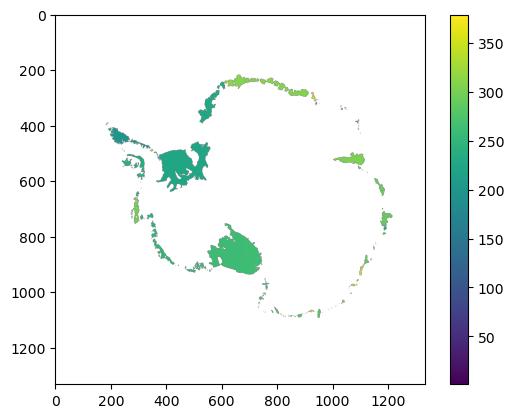

In [121]:
plt.imshow(id_map)
plt.colorbar()
plt.show()

In [122]:
groups = id_map

In [179]:
uniq_shelf = np.unique(groups)
slope_map = np.full(xx_bm.shape, np.nan)

for shelf_id in uniq_shelf:
    if shelf_id==0:
        continue
    mask_shelf = groups==shelf_id
    if np.count_nonzero(mask_shelf)>10:
        X = ii[mask_shelf]
        X -= X.min()
        Y = jj[mask_shelf]
        Y -= Y.min()
        b = icebottom[mask_shelf]
    
        A = np.vstack([X,Y, np.ones(len(X))]).T
        m1, m2, c = np.linalg.lstsq(A, b, rcond=None)[0]
        m1 = np.abs(m1/5000)
        m2 = np.abs(m2/5000)
        slope_shelf = np.sqrt(m1**2+m2**2)
        slopes[shelf_id] = slope_shelf
    
        slope_map[mask_shelf] = slope_shelf

In [180]:
melts2 = cdws_grid * heats_grid *gprimes_grid * slope_map * fs

In [181]:
hydro = cdws_grid * heats_grid *gprimes_grid * fs

In [182]:
dotson_id = joined.loc[joined.NAME=='Crosson', 'index_right'].unique()[0]
dotson_id

np.int64(247)

In [183]:
melts2[(id_map==dotson_id) & (boundary_msk==True)].mean()

np.float64(33.980310803847345)

In [184]:
# joined.NAME.unique()

In [185]:
np.unique(slope_map[id_map==dotson_id])

array([0.0081653])

In [186]:
hydro[(id_map==dotson_id) & (boundary_msk==True)].mean()

np.float64(4161.550403867393)

In [187]:
slopes_list = []
hydro_list = []
melt_list = []

for name in joined.NAME.unique():
    tmp_id = joined.loc[joined.NAME==name, 'index_right'].unique()[0]
    slopes_list.append(np.unique(slope_map[id_map==tmp_id])[0])
    hydro_list.append(hydro[(id_map==tmp_id) & (boundary_msk==True)].mean())
    melt_list.append(melts2[(id_map==tmp_id) & (boundary_msk==True)].mean())

In [188]:
slopes_list = np.array(slopes_list)
hydro_list = np.array(hydro_list)
melt_list = np.array(melt_list)

bad = np.isnan(slopes_list) | np.isnan(hydro_list) | np.isnan(melt_list)

In [189]:
slopes_list = slopes_list[~bad]
hydro_list = hydro_list[~bad]
melt_list = melt_list[~bad]

In [190]:
from sklearn.linear_model import LinearRegression

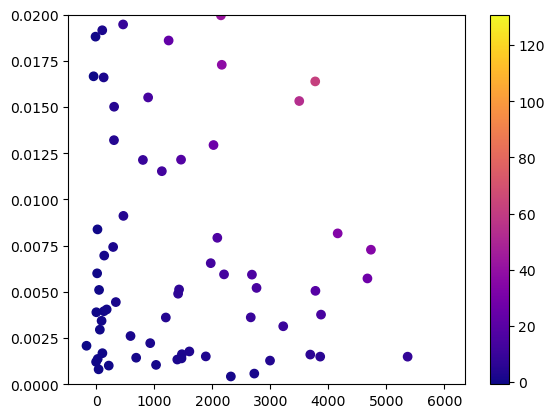

In [191]:
plt.scatter(hydro_list, slopes_list, c=melt_list, cmap='plasma')
plt.colorbar()
plt.ylim(0, 0.02)
plt.show()

In [192]:
df_ada = pd.read_csv(Path('../raw_data/adasumilli.csv'))
df_ada

,Name,basal_melt,uncertainty
0,George VI,4.3,2.2
1,Bach,3.2,2.1
2,Wilkins,2.7,3.4
3,Strange,3.7,2.1
4,Venable,5.1,2.0
5,Abbot,1.5,1.5
6,Cosgrove,1.0,1.5
7,Pine_Island,14.0,1.6
8,Thwaites,26.7,2.4
9,Crosson,7.8,1.8


In [193]:
np.sort(joined.NAME.unique())

array(['Abbot', 'Ainsworth', 'Amery', 'Andreyev', 'Arneb', 'Astrolabe',
       'Atka', 'Aviator', 'Bach', 'Baudouin', 'Borchgrevink', 'Brahms',
       'Brunt_Stancomb', 'Campbell', 'Cheetham', 'Chugunov',
       'Cirque_Fjord', 'ClarkeBay', 'Commandant_Charcot',
       'Conger_Glenzer', 'Cook', 'Cosgrove', 'Crosson', 'Dalk',
       'Dawson_Lambton', 'Deakin', 'Dennistoun', 'Dibble', 'Dotson',
       'Drury', 'Drygalski', 'Edward_VIII', 'Ekstrom', 'Erebus',
       'Ferrigno', 'Filchner', 'Fimbul', 'Fisher', 'Fitzgerald',
       'Flatnes', 'Fox', 'Francais', 'Frost', 'Gannutz', 'Garfield',
       'GeikieInlet', 'George_VI', 'Getz', 'Gillet', 'Hamilton',
       'Hamilton_Piedmont', 'Hannan', 'HarbordGlacier', 'Harmon_Bay',
       'Helen', 'Holmes', 'Holt', 'HornBluff', 'Hoseason', 'Hovde',
       'Hull', 'Hummer_Point', 'Ironside', 'Jackson', 'Jelbart', 'Land',
       'LarsenA', 'LarsenB', 'LarsenC', 'LarsenD', 'LarsenE', 'LarsenF',
       'LarsenG', 'Lauritzen', 'Lazarev', 'Lillie', 'Lio

In [194]:
dotson_id = joined.loc[joined.NAME=='Getz', 'index_right'].unique()[0]

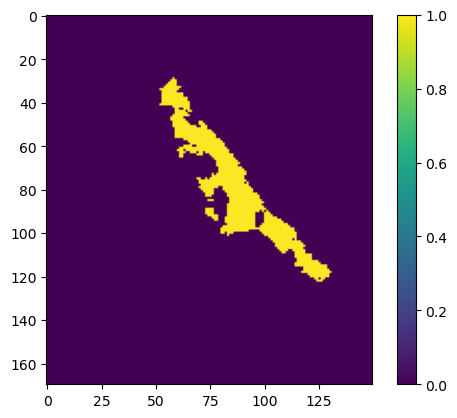

In [195]:
plt.imshow(id_map[780:950,300:450]==dotson_id)
plt.colorbar()
plt.show()

In [196]:
df_ada['good'] = df_ada.Name.isin(joined.NAME)

In [197]:
df_ada.loc[df_ada.good==True, 'Name'].sort_values()

5                 Abbot
40                 Atka
1                  Bach
34             Baudouin
35         Borchgrevink
30       Brunt_Stancomb
23                 Cook
6              Cosgrove
9               Crosson
10               Dotson
18            Drygalski
33              Ekstrom
43             Filchner
37               Fimbul
11                 Getz
25               Holmes
41              Jelbart
12                 Land
46              LarsenB
45              LarsenC
44              LarsenD
36              Lazarev
20              Mariner
24                Mertz
21    Moscow_University
19               Nansen
13            Nickerson
38                 Nivl
7           Pine_Island
29        Prince_Harald
32                 Quar
22              Rennick
31        Riiser-Larsen
42                Ronne
17            Ross_East
16            Ross_West
27           Shackleton
14           Sulzberger
8              Thwaites
26               Totten
4               Venable
39              

In [198]:
slopes_list = []
hydro_list = []
melt_list = []

for i, ada_name in enumerate(df_ada.Name):
    if df_ada.good.iloc[i] == True:
        tmp_id = joined.loc[joined.NAME==ada_name, 'index_right'].unique()[0]
        slopes_list.append(np.unique(slope_map[id_map==tmp_id])[0])
        hydro_list.append(hydro[(id_map==tmp_id) & (boundary_msk==True)].mean())
        melt_list.append(melts2[(id_map==tmp_id) & (boundary_msk==True)].mean())
    else:
        slopes_list.append(np.nan)
        hydro_list.append(np.nan)
        melt_list.append(np.nan)

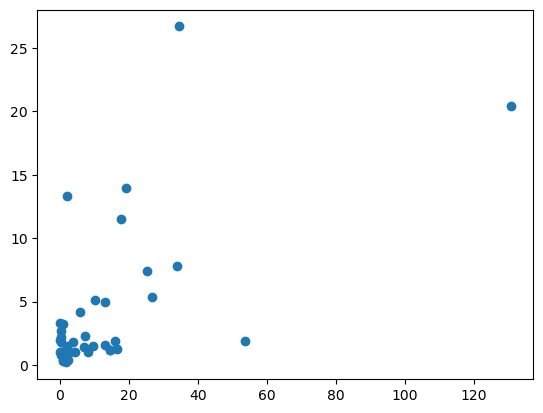

In [199]:
plt.plot(melt_list, df_ada.basal_melt, 'o')
plt.show()

In [200]:
x = np.array(melt_list)
y = df_ada.basal_melt.values
good_vals = ~np.isnan(x)
x = x[good_vals]
y = y[good_vals]

x = x.reshape(-1,1)

In [201]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x, y)
x2 = model.predict(x)

In [202]:
xi = np.linspace(0, 100, 100)
yi = model.predict(xi.reshape((-1,1)))

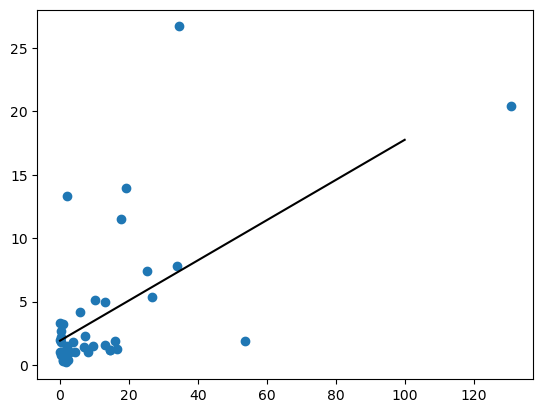

In [203]:
plt.plot(x, y, 'o')
# plt.plot(x2, y, 'ro')
plt.plot(xi, yi, '-k')
# plt.axis('scaled')
# plt.plot(range(20),range(20))
plt.show()

In [147]:
df_ada['pred_melt'] = melt_list

In [148]:
df_ada

,Name,basal_melt,uncertainty,good,pred_melt
0,George VI,4.3,2.2,False,NaN
1,Bach,3.2,2.1,True,0.788683
2,Wilkins,2.7,3.4,True,NaN
3,Strange,3.7,2.1,False,NaN
4,Venable,5.1,2.0,True,6.425761
5,Abbot,1.5,1.5,True,NaN
6,Cosgrove,1.0,1.5,True,6.504780
7,Pine_Island,14.0,1.6,True,17.427720
8,Thwaites,26.7,2.4,True,NaN
9,Crosson,7.8,1.8,True,27.659418


In [149]:
ds_melt = xr.open_dataset(Path('../raw_data/adasumilli_basal_melt.h5'))
ds_melt

<xarray.Dataset> Size: 3GB
Dimensions:     (phony_dim_0: 10229, phony_dim_1: 10941, phony_dim_2: 1)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Data variables:
    w_b         (phony_dim_0, phony_dim_1) float64 895MB ...
    w_b_interp  (phony_dim_0, phony_dim_1) float64 895MB ...
    w_b_uncert  (phony_dim_0, phony_dim_1) float64 895MB ...
    x           (phony_dim_1, phony_dim_2) float64 88kB ...
    y           (phony_dim_0, phony_dim_2) float64 82kB ...
Attributes:
    Version:  v0

In [215]:
ds_melt.x

<xarray.DataArray 'x' (phony_dim_1: 10941, phony_dim_2: 1)> Size: 88kB
[10941 values with dtype=float64]
Dimensions without coordinates: phony_dim_1, phony_dim_2
Attributes:
    description:  PS-71 x in m

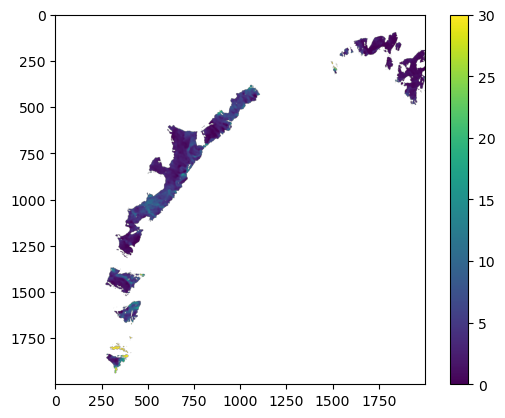

In [216]:
plt.imshow(ds_melt.w_b.values[2000:4000,2000:4000], vmin=0, vmax=30)
plt.colorbar()
plt.show()

# Merging bathymetries into 5 km grid

In [231]:
beds, losses = get_beds(Path('../iceshelves/abbot/results_gn'))

In [233]:
beds.shape

(200, 130, 70)

In [150]:
xx_bm.shape

(1333, 1333)

In [171]:
ensembles = []
merged_maps = np.full((200, *xx_bm.shape), np.nan)
msks = np.full(xx_bm.shape, False)

for i, entry in enumerate(os.scandir(Path('../iceshelves'))):
    if (entry.name.startswith('.')==False) & (entry.name != 'pineisland_new'):
        print(entry.name)

        with os.scandir(entry.path) as iceshelf_files:
                for iceshelf_file in iceshelf_files:
                    if iceshelf_file.name.endswith('.nc'):
                        dataset_path = iceshelf_file.path
    
        ds_i = xr.load_dataset(dataset_path)
        
        beds, losses = get_beds(Path(entry.path)/'results_gn')

        xx_i, yy_i = np.meshgrid(ds_i.x, ds_i.y)

        xmin = np.min(xx_i)
        xmax = np.max(xx_i)
        ymin = np.min(yy_i)
        ymax = np.max(yy_i)
        msk_i = (xx_bm > xmin) & (xx_bm < xmax) & (yy_bm > ymin) & (yy_bm < ymax)
        msks += msk_i

        for j in range(200):
            bed_j = beds[j,...] - ds_i.geoid.values
            kn = vd.KNeighbors(k=1)
            kn.fit((xx_i, yy_i), bed_j)
            preds_j = kn.predict((xx_bm[msk_i], yy_bm[msk_i]))
    
            merged_maps[j,...] = np.where(msk_i, emplace_data(msk_i, preds_j), merged_maps[j,...])

        ensembles.append(beds)

abbot
george
larsen
maudeast
maudwest
salzberger
shackleton
totten
pineisland
getz


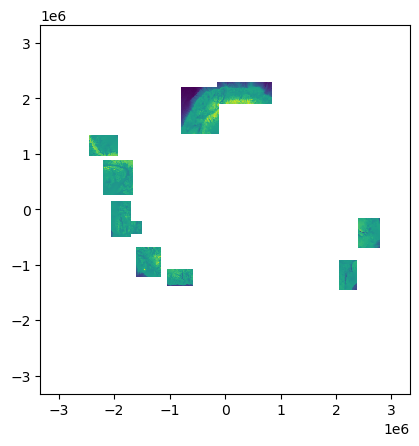

In [172]:
plt.pcolormesh(ds.x, ds.y, merged_maps[0,...])
plt.axis('scaled')
plt.show()

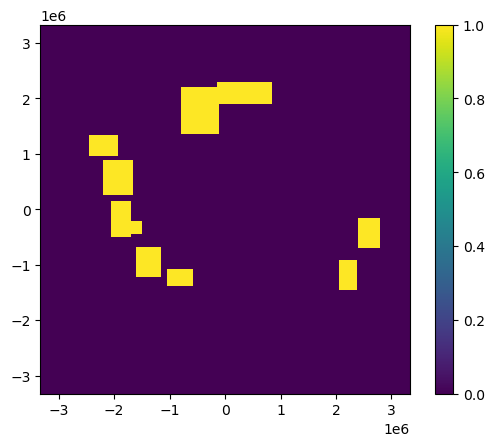

In [173]:
plt.pcolormesh(ds.x, ds.y, msks)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [174]:
for j in range(200):
    merged_maps[j,...] = np.where((msks==True) & (ds.mask==3), merged_maps[j,...], ds.bed.values)

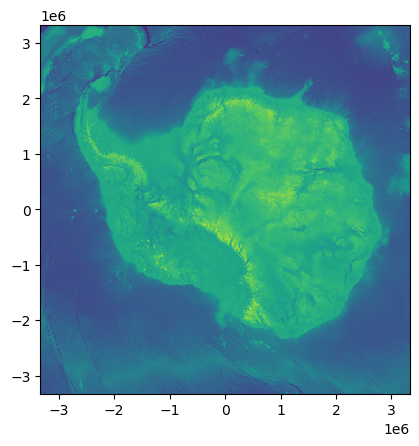

In [175]:
plt.pcolormesh(ds.x, ds.y, merged_maps[0,...])
plt.axis('scaled')
plt.show()

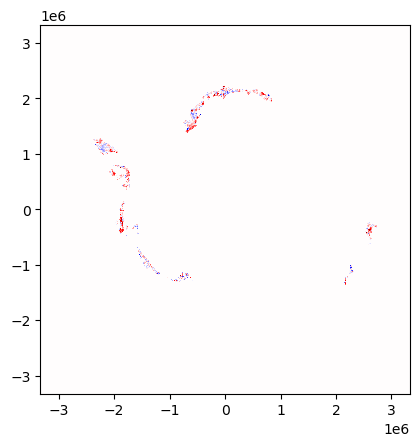

In [178]:
plt.pcolormesh(ds.x, ds.y, ds.bed.values - merged_maps[0,...], cmap='seismic', vmin=-1000, vmax=1000)
plt.axis('scaled')
plt.show()

In [206]:
melt_grids = np.full((200, *xx_bm.shape), np.nan)

for j in tqdm(range(200)):
    hubs = hub_elevations(ds, merged_maps[j,...], water_msk, min_bed, max_bed, vert_res, save_connects=False, quiet=True)
    hubs = np.where(hubs > 0, 0, hubs)

    baths = hubs[boundary_msk]
    
    for i in range(n_gl):
        tinterp = make_interp_spline(d, t[:,i])
        sinterp = make_interp_spline(d, s[:,i])
    
        lon = lons[i]
        lat = lats[i]
        
        if np.isnan(t[11:,i]).all():
            heats[i] = np.nan
            
        elif np.nanmax(d[~np.isnan(t[:,i])]) > np.abs(baths[i]):
            heats[i] = heat_content((tinterp,sinterp), baths[i], 100)
            cdws[i] = pycnocline((tinterp,sinterp), baths[i], shelf_key=None, lat=lat, lon=lon)
            gprimes[i] = gprime((tinterp,sinterp), baths[i], shelf_key=None, lat=lat, lon=lon)
    
    heats_grid = emplace_data(boundary_msk, heats)
    cdws_grid = emplace_data(boundary_msk, cdws)
    gprimes_grid = emplace_data(boundary_msk, gprimes)

    melt_grids[j,...] = cdws_grid * heats_grid *gprimes_grid * slope_map * fs

  0%|          | 0/200 [00:00<?, ?it/s]

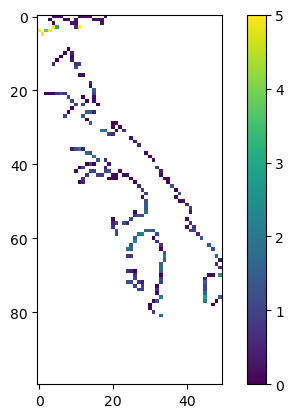

In [212]:
plt.imshow(np.std(melt_grids, axis=0)[800:900,350:400], vmax=5)
plt.colorbar()
plt.show()

In [213]:
uniq_names = joined.NAME.unique()
len(uniq_names)

156

In [217]:
melt_ensemble = np.full((200, len(df_ada.Name)), np.nan)

for i in tqdm(range(200)):
    for j, ada_name in enumerate(df_ada.Name):
        if df_ada.good.iloc[j] == True:
            tmp_id = joined.loc[joined.NAME==ada_name, 'index_right'].unique()[0]
            melt_ensemble[i,j] = melt_grids[i,...][(id_map==tmp_id) & (boundary_msk==True)].mean()

  0%|          | 0/200 [00:00<?, ?it/s]

In [218]:
melt_ensemble.shape

(200, 47)

In [219]:
melt_unc = np.std(melt_ensemble, axis=0)
melt_unc.shape

(47,)

In [220]:
df_ada['melt_unc'] = melt_unc
df_ada

,Name,basal_melt,uncertainty,good,melt_unc
0,George VI,4.3,2.2,False,NaN
1,Bach,3.2,2.1,True,2.013855e-01
2,Wilkins,2.7,3.4,True,NaN
3,Strange,3.7,2.1,False,NaN
4,Venable,5.1,2.0,True,9.139641e-01
5,Abbot,1.5,1.5,True,NaN
6,Cosgrove,1.0,1.5,True,5.745833e-01
7,Pine_Island,14.0,1.6,True,4.773213e-01
8,Thwaites,26.7,2.4,True,4.226238e-01
9,Crosson,7.8,1.8,True,2.294458e-01


In [222]:
df_ada.sort_values(by=['melt_unc'], ascending=False)

,Name,basal_melt,uncertainty,good,melt_unc
12,Land,20.4,2.7,True,1.606801e+00
39,Vigrid,1.2,1.0,True,1.501304e+00
4,Venable,5.1,2.0,True,9.139641e-01
41,Jelbart,1.0,1.1,True,8.494964e-01
13,Nickerson,1.2,1.4,True,6.441197e-01
6,Cosgrove,1.0,1.5,True,5.745833e-01
7,Pine_Island,14.0,1.6,True,4.773213e-01
8,Thwaites,26.7,2.4,True,4.226238e-01
10,Dotson,5.4,1.6,True,3.652822e-01
9,Crosson,7.8,1.8,True,2.294458e-01


In [223]:
x = np.array(melt_list)
y = df_ada.basal_melt.values
good_vals = ~np.isnan(x)
x = x[good_vals]
y = y[good_vals]

err = melt_unc[good_vals]

x = x.reshape(-1,1)

In [201]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x, y)
x2 = model.predict(x)

In [202]:
xi = np.linspace(0, 100, 100)
yi = model.predict(xi.reshape((-1,1)))

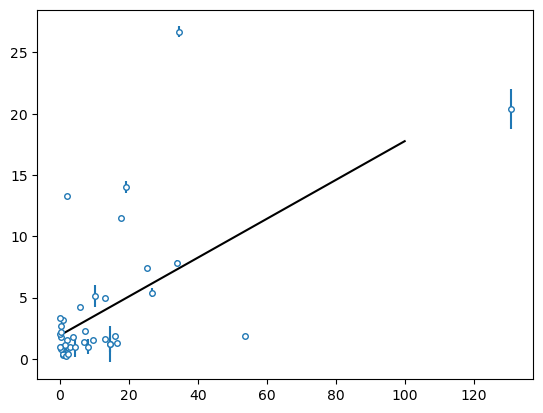

In [239]:
# plt.plot(x, y, 'o')
plt.errorbar(x, y, yerr=err, fmt='o', ms=4, mfc='w')
# plt.plot(x2, y, 'ro')
plt.plot(xi, yi, '-k')
# plt.axis('scaled')
# plt.plot(range(20),range(20))
plt.show()

In [226]:
err

array([2.01385527e-01,            nan, 9.13964060e-01,            nan,
       5.74583284e-01, 4.77321340e-01, 4.22623788e-01, 2.29445801e-01,
       3.65282168e-01, 8.46256415e-02, 1.60680101e+00, 6.44119681e-01,
                  nan, 8.67361738e-18, 6.66133815e-16, 1.55431223e-15,
       3.55271368e-14, 1.77635684e-15, 1.93905717e-01, 2.30926389e-14,
       7.10542736e-14, 4.79616347e-14, 3.10862447e-15, 6.60667436e-02,
                  nan, 7.10542736e-15, 1.50990331e-14, 1.35438209e-01,
                  nan, 7.07125491e-02, 2.58732105e-02, 1.08246745e-15,
                  nan, 7.49364395e-02, 1.15057043e-01, 1.19718385e-01,
       1.50130418e+00, 6.89401468e-02, 8.49496437e-01, 4.44089210e-15,
       8.43769499e-15,            nan,            nan,            nan])